In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Exercise 6.1: Results Compilation

In [3]:
file_path = Path("model_analysis/ex_06")
file_path.mkdir(parents=True, exist_ok=True)

plot_path = Path("plots/ex_06")
plot_path.mkdir(parents=True, exist_ok=True)

In [4]:
# load CSV
df = pd.read_csv("model_analysis/ex_05/model_evaluation_metrics.csv")

# define weights for each metric
weights = {
    'f1_macro_mean': 0.4,
    'recall_macro_mean': 0.3,
    'roc_auc_mean': 0.3
}

# compute weighted average score
df['weighted_score'] = (
    df['f1_macro_mean'] * weights['f1_macro_mean'] +
    df['recall_macro_mean'] * weights['recall_macro_mean'] +
    df['roc_auc_mean'] * weights['roc_auc_mean']
)

# sort and get top 3 models, make new df only of best models
top_models = df.sort_values(by='weighted_score', ascending=False).head(3)
top_model_names = top_models['model']
df_top_models = df[df['model'].isin(top_model_names)].copy()

# split model name into classifier and feature set
split_model = df_top_models['model'].str.rsplit('_', n=1, expand=True)
df_top_models['Classifier'] = split_model[0]
df_top_models['Feature_Set'] = split_model[1]

# select and rename relevant columns
summary_df = df_top_models[['Classifier', 'Feature_Set',
                'f1_macro_mean', 'f1_macro_std', 
                'recall_macro_mean', 'recall_macro_std',
                'roc_auc_mean', 'roc_auc_std']]

summary_df.columns = ['Classifier', 'Feature Set', 
                      'F1 Mean', 'F1 Standard Deviation',
                      'Recall Mean', 'Recall Standard Deviation', 
                      'ROC AUC Mean', 'ROC AUC Standard Deviation']

# sort by F1 value and write to markdown
summary_df = summary_df.sort_values(by='F1 Mean', ascending=False)

md_table = summary_df.to_markdown(index=False)
display(Markdown(md_table))

with open(file_path/"best_model_summary.md", "w") as f:
    f.write(md_table)


| Classifier        | Feature Set   |   F1 Mean |   F1 Standard Deviation |   Recall Mean |   Recall Standard Deviation |   ROC AUC Mean |   ROC AUC Standard Deviation |
|:------------------|:--------------|----------:|------------------------:|--------------:|----------------------------:|---------------:|-----------------------------:|
| Random_Forest     | Raw           |  0.840462 |             0.000591744 |      0.839846 |                 0.000553727 |       0.930353 |                  0.000180494 |
| Gradient_Boosting | Raw           |  0.828388 |             0.000548865 |      0.833612 |                 0.000474143 |       0.919827 |                  7.07658e-05 |
| Random_Forest     | Extracted     |  0.820011 |             0.000927958 |      0.820711 |                 0.000941652 |       0.914615 |                  9.25801e-05 |

## 6.2: Results Visualization and Discussion

In [5]:
# split model name into classifier and feature set
split_model = df['model'].str.rsplit('_', n=1, expand=True)
df['Classifier'] = split_model[0]
df['Feature_Set'] = split_model[1]

# select and rename relevant columns
complete_df = df[['Classifier', 'Feature_Set',
                'f1_macro_mean', 'f1_macro_std', 
                'recall_macro_mean', 'recall_macro_std',
                'roc_auc_mean', 'roc_auc_std']]

complete_df.columns = ['Classifier', 'Feature Set', 
                      'F1 Mean', 'F1 Standard Deviation',
                      'Recall Mean', 'Recall Standard Deviation', 
                      'ROC AUC Mean', 'ROC AUC Standard Deviation']

### Plots:

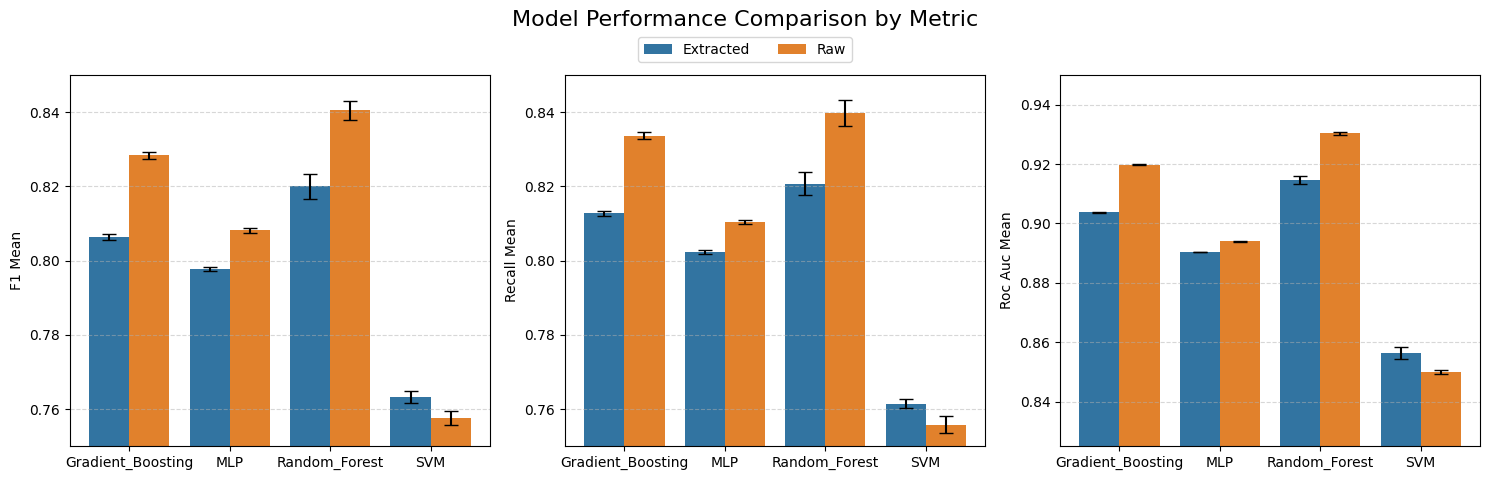

In [ ]:
metrics = {
    'F1 Mean': 'F1 Standard Deviation',
    'Recall Mean': 'Recall Standard Deviation',
    'ROC AUC Mean': 'ROC AUC Standard Deviation'
}

metric_ylim = {
    'F1 Mean': (0.75, 0.85),
    'Recall Mean': (0.75, 0.85),
    'ROC AUC Mean': (0.825, 0.95)
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=False)
fig.suptitle("Model Performance Comparison by Metric", fontsize=16)

# Plot each metric on a subplot
for ax, (metric, std) in zip(axes, metrics.items()):
    plot = sns.barplot(
        data=complete_df,
        x='Classifier',
        y=metric,
        errorbar=('ci', None),
        hue='Feature Set',
        ax=ax,
        capsize=0.1,
        err_kws={'linewidth': 1.5}
    )

    # extract and remove legend of subplot
    handles, labels = ax.get_legend_handles_labels()
    ax.legend_.remove()

    # Add manual error bars
    # Get grouped dataframe in the same order as plotted bars
    grouped = complete_df.groupby(['Classifier', 'Feature Set'])[[metric, std]].first().reset_index()

    # Track bar count to map errors correctly
    for bar, (_, row) in zip(plot.patches, grouped.iterrows()):
        height = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        std_dev = row[std]
        ax.errorbar(x, height, yerr=std_dev, fmt='none', c='black', capsize=5)

    ax.set_ylabel(metric.replace("_macro_mean", '').replace('_', ' ').title())
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_ylim(*metric_ylim[metric])

# add one general legend across all subplots
fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 0.94))

# Adjust layout
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save as a single file
plt.savefig(plot_path / "model_evaluation_metrics.png", dpi=300)
plt.show()

### Confusion Matrices:

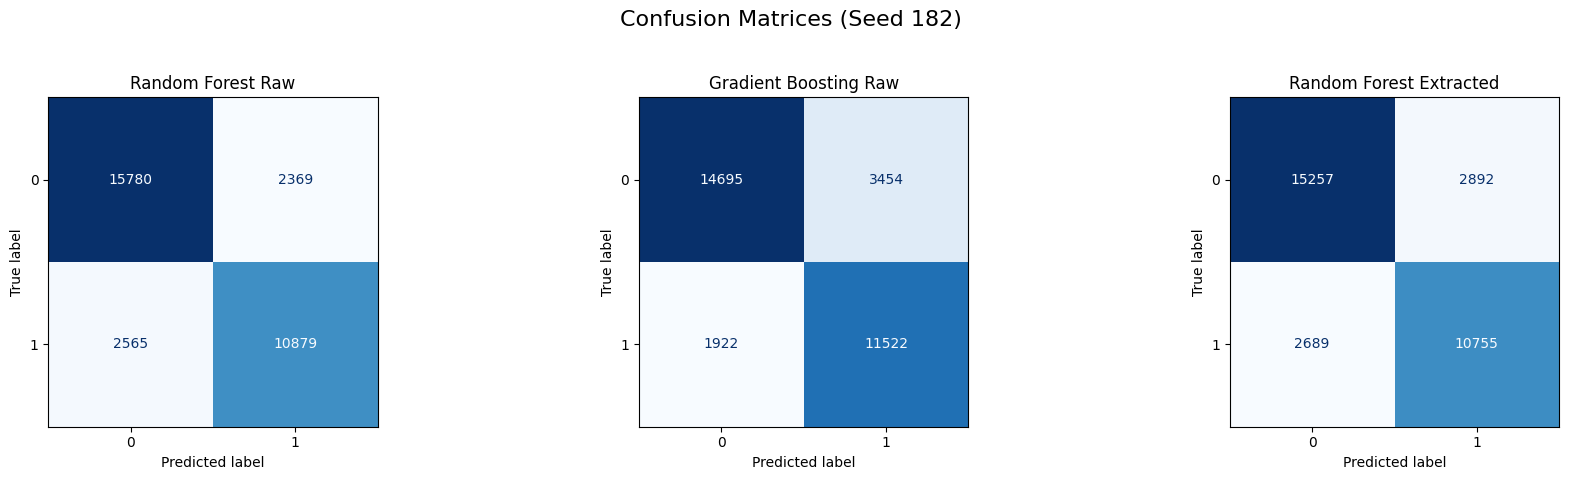

In [ ]:
seed = 182

raw_data_path = Path("model_analysis/ex_05/label_prediction")

labels_test = pd.read_csv(raw_data_path / "labels_test_true.csv").values.ravel()

# Create a single figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Confusion Matrices (Seed {seed})", fontsize=16)

# Plot each confusion matrix
for ax, model_name in zip(axes, top_model_names):
    labels_pred = pd.read_csv(raw_data_path / f"{model_name}_seed_{seed}_labels_pred.csv").values.ravel() # transform pd df into a np array
    
    cm = confusion_matrix(labels_test, labels_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    ax.set_title(model_name.replace('_', ' '))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the figure
plt.savefig(plot_path/ "confusion_matrices.png", dpi=300)
plt.show()

### Discussion

#### **1. Which models performed best overall, and on which feature sets?**
The overall best performing model was the `Random Forest` Ensemble used on the **raw** dataset with an f1 score of ~0.84, a recall score of ~0.84 and a ROC AUC score of ~0.93.


#### **2. Were there significant differences in performance between using engineered features and raw time-series data? Why might this be?**
Generally models trained on engineered features performed worse than raw time-series data. With consideration to the error-bars, this difference appears to be non-incidental. This is likely caused by a loss of crucial information for differentiating quality classes when extracting engineered features. However some of the extracted features must still contain importating differentiating information, as the engingeered feature mode performance is not behind by a large amount (approx. between 0.01-0.02 per metric).

The only exception was the SVM classifier, where engineered features displayed better performance. SVM generally works better for smaller sets of data and features. This might be the cause for the improved performance of the selected engineered features over the larger amount of raw time-series data. The SVM model may also have overfitted on the raw time-series training data, which may have been mitigated by the lower amount of engineered features.


#### **3. How do the chosen evaluation metrics reflect the models' ability to distinguish between good and bad quality welds?**

The chosen evaluation metrics all reflect a models' ability to correctly identify a good and bad weld. In all metrics the `Random Forest` classifier with a raw dataset displays scores than the other two best performing models. This is reflected in its performance of correctly identifying qualtiy class in ~84.39% of welds. The next best performing model in all metrics - the `Gradient Boosting` model with the raw dataset - correctly identifies quality class in ~82.99% of welds, whereas the third best performing model - `Random Forest` on engineered features - is able to correctly identify quality class in ~82.34% of welds.

The chosen evaluation metrics do not seem to show any distinguishment between different error types, as the `Gradient Boosting` classifier on raw data might misclassify data in slightly more cases than the `Random Forest` on raw data, however it more often makes false positive predictions (3454 cases) than false negative predictions (1922 cases). In the welding context false positives are more costly than false negatives, as a faulty weld would go on in the production chain undetected. This drawback of the `Gradient Boosting` classifier is *not* reflected in the chosen evaluation metrics.